# Hydro Power Projects — Supply Chain Impact Analysis  ·  Tiers 0–10

Multi-tier, multi-database supply-chain impact assessment for three hydro power
projects from the FAST-Infra labelling dataset spanning Africa, Asia, and Europe.
All four calibrated MRIO databases (EXIOBASE 3.8, Eora26, WIOD 2016,
OECD ICIO v2021) are run in parallel so cross-database uncertainty can be read
directly from the results.

**Supply-chain tier convention:**
> **Tier 0** — the project's own one-time transaction: CAPEX paid directly to
> civil engineering contractors, turbine manufacturers, electrical equipment
> suppliers, etc. (`SECTOR_ALLOC` vector for the `Energy` sector code).
> One sector, one country per line item.  Impact indicators shown in Section 4.
> No Leontief inversion.
>
> **Tier 1** — the Tier 0 spend aggregated into the upstream supply chain.  Each
> Tier 0 supplier now buys its own inputs from different sectors and countries.
> This is `y₁ = A · y₀` and includes a bilateral sourcing-country breakdown.
>
> **Tier n** — the n-th upstream round: `yₙ = Aⁿ · y₀`.

| Project ID | Region | Stage | Investment (USD) | Impact type | Avoided CO₂ (tCO2e/yr) |
|---|---|---|---|---|---|
| **Hydro_AF** | Africa | Construction | $30,000,000 | Refurbishment | 150,000 |
| **Hydro_AS** | Asia | Development | $150,000,000 | Large-scale retrofit | 834,219 |
| **Hydro_EU** | Europe | Operation | $2,000,000 | Efficiency tweak | 6,126 |

All three projects use the `Energy` sector code (hydro / renewable power plant).
The avoided-emissions figures represent the annual GHG displacement from grid
carbon once the project is operational — they are **not** supply-chain impacts
(which this notebook quantifies).

### Analysis layers
| Layer | What it captures |
|---|---|
| **Tier 0** | One-time transaction — CAPEX distributed across direct supplying sectors; impact shown per sector (`y₀ = alloc × invest_M$`) |
| **Tier 1** | First upstream round — Tier 0 spend aggregated into the supply chain across sectors and countries (`y₁ = A · y₀`) + bilateral sourcing-country breakdown |
| **Tier 2** | Second upstream round — Tier 1 suppliers' own supply chain (`y₂ = A² · y₀`) |
| **Tiers 3–10** | Deep upstream rounds, per-tier and aggregated (`yₙ = Aⁿ · y₀`) |
| **Cumulative** | T0 + T1 + T2 + T3–10 stacked by tier group |


In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:,.3f}".format)
pd.set_option("display.max_columns", 20)

sys.path.insert(0, str(Path(".").resolve()))
from tvp_io_lib import tier0_impact, tier1_impact, tier_impact

IODB      = Path(".") / "input_iodb"
DATABASES = ["exiobase", "eora26", "wiod", "oecd"]
DB_LABEL  = {
    "exiobase": "EXIOBASE 3.8",
    "eora26":   "Eora26",
    "wiod":     "WIOD 2016",
    "oecd":     "OECD ICIO v2021",
}
INDICATORS = ["GHG_tCO2e", "Employment_FTE", "Water_1000m3", "ValueAdded_M$"]
DB_COLORS  = ["#2166ac", "#d73027", "#4dac26", "#f1a340"]

# All investments already in USD (hydro_finance_input.csv: Est_Investment_USD)
PROJECTS = [
    {"id": "Hydro_AF", "region": "Africa", "stage": "Construction",
     "sector_code": "Energy", "invest_usd": 30_000_000,
     "impact_type": "Refurbishment",       "avoided_co2": 150_000},
    {"id": "Hydro_AS", "region": "Asia",   "stage": "Development",
     "sector_code": "Energy", "invest_usd": 150_000_000,
     "impact_type": "Large-scale retrofit", "avoided_co2": 834_219},
    {"id": "Hydro_EU", "region": "Europe", "stage": "Operation",
     "sector_code": "Energy", "invest_usd": 2_000_000,
     "impact_type": "Efficiency tweak",    "avoided_co2": 6_126},
]

print("Setup complete.")
print(f"  {'Project':<12} {'Region':<8} {'Stage':<14} {'Invest_MUSD':>12}  {'Impact type':<22} {'Avoided CO2/yr':>14}")
for p in PROJECTS:
    print(f"  {p['id']:<12} {p['region']:<8} {p['stage']:<14} "
          f"  ${p['invest_usd']/1e6:>7.2f}M  {p['impact_type']:<22} {p['avoided_co2']:>14,.0f} tCO2e")


Setup complete.
  Project      Region   Stage           Invest_MUSD  Impact type            Avoided CO2/yr
  Hydro_AF     Africa   Construction     $  30.00M  Refurbishment                 150,000 tCO2e
  Hydro_AS     Asia     Development      $ 150.00M  Large-scale retrofit          834,219 tCO2e
  Hydro_EU     Europe   Operation        $   2.00M  Efficiency tweak                6,126 tCO2e


---
## 1 · Source Data

### Financial Model Inputs (`modeled_input_data/`)

| Field | Type | Description |
|---|---|---|
| `Sector` | string | IO sector code: `Energy` for all three hydro projects (hydro / renewable power plant archetype) |
| `Avoided_CO2_Tons` | float | Annual CO₂ avoidance in tonnes — used for carbon-intensity benchmarking but not in the IO model |
| `Est_Investment_USD` | float | Estimated total investment in USD.  Already in USD — no currency conversion required |
| `Impact_Type` | categorical | Engineering classification of the investment: `Refurbishment` (Hydro_AF), `Large_Scale_Retrofit` (Hydro_AS), `Efficiency_Tweak` (Hydro_EU) |

> **Scale note:** The three projects span two orders of magnitude — $150M (Hydro_AS),
> $30M (Hydro_AF), $2M (Hydro_EU).  The avoided-CO₂ figures reflect the
> "Carbon-Displacement Link" assumption: regional grid emission factors are applied
> to the MW capacity upgraded (see `modeled_input_data/assumptions.txt`, Section 2).
> Hydro_AS displaces coal-heavy Asian generation (high grid intensity);
> Hydro_EU is a small efficiency improvement on an already low-carbon European grid.

> **All three projects share the `Energy` sector code** (`SECTOR_ALLOC["Energy"]`):
> Construction 38%, Manufacturing 32%, Water/Waste 7%, Energy/Utilities 10%,
> Transport/Logistics 7%, Mining/Extraction 3%, Health/Social 1%, Agriculture 2%.
> The high Manufacturing share (32%) reflects the turbine runner, generator rewinding,
> and power electronics that dominate hydro refurbishment costs.


In [2]:
finance_df = pd.read_csv("modeled_input_data/hydro_finance_input.csv")
display(finance_df)

,Project_ID,Region,Sector,Avoided_CO2_Tons,Est_Investment_USD,Impact_Type
0,Hydro_AF,Africa,Energy,150000,30000000,Refurbishment
1,Hydro_AS,Asia,Energy,834218,150000000,Large_Scale_Retrofit
2,Hydro_EU,Europe,Energy,6126,2000000,Efficiency_Tweak


---
## 2 · MRIO Databases

All four calibrated databases are run in parallel.  When local files exist under
`input_iodb/` the pymrio backend is activated and bilateral trade shares are
extracted directly from the Z matrix; otherwise the calibrated parameter set
(derived from EXIOBASE 3.8 aggregates) is applied.

For hydro projects the choice of database is particularly significant for:
- **GHG at Tier 0 (Energy/Utilities intensity):** Africa carries a 1.90× multiplier
  vs. the global average (diesel/coal generation), Europe a 0.52× multiplier
  (high renewables/nuclear share).  EXIOBASE 3.8 provides the most granular
  regional breakdown of electricity-sector GHG intensity.
- **Manufacturing GHG (turbines, generators):** Hydro_AS sources most of its
  heavy equipment from Asian manufacturers.  Eora26's 190-country resolution
  captures intra-Asian supply chains better than EXIOBASE's RoW Asia aggregate.
- **Employment (Tier 0):** Africa's construction employment multiplier is ≈ 1.58×
  the global average.  WIOD's Socio-Economic Accounts give the most reliable
  European employment figures for Hydro_EU.

| Database | Coverage | Data year | Key strength | Key limitation | Citation |
|---|---|---|---|---|---|
| **EXIOBASE 3.8** | 44 countries + 5 RoW · 163 sectors | 2018 | Widest environmental satellite (GHG species, water, land, materials) | Employment less detailed for services | Stadler et al. (2018), *J. Industrial Ecology* 22(3), doi:10.1111/jiec.12715 |
| **Eora26** | 190 countries · 26 sectors | 2015 | Highest country resolution — essential for Africa, Asia | 26 sectors; upward employment bias in developing countries | Lenzen et al. (2013), *Economic Systems Research* 25(1), doi:10.1080/09535314.2012.761953 |
| **WIOD 2016** | 43 countries + RoW · 56 sectors | 2014 | Best employment accounts (SEA: hours, compensation, skill levels) | No water satellite account | Timmer et al. (2015), *Review of International Economics* 23(3), doi:10.1111/roie.12178 |
| **OECD ICIO v2021** | 66 countries · 45 sectors | 2018 | Most policy-relevant; fully aligned with OECD TiVA; best for value-added decomposition | Fewer sectors; limited environmental satellite | OECD (2021), doi:10.1787/a8c8b9f0-en |


In [3]:
db_meta = pd.DataFrame([
    {"Database": "EXIOBASE 3.8",    "Countries": "44+5RoW", "Sectors": 163,
     "Data year": 2018, "Water satellite": "Yes",  "Employment satellite": "Basic"},
    {"Database": "Eora26",          "Countries": "190",     "Sectors": 26,
     "Data year": 2015, "Water satellite": "No",   "Employment satellite": "Yes (bias in dev. countries)"},
    {"Database": "WIOD 2016",       "Countries": "43+RoW",  "Sectors": 56,
     "Data year": 2014, "Water satellite": "No",   "Employment satellite": "Detailed (SEA)"},
    {"Database": "OECD ICIO v2021", "Countries": "66",      "Sectors": 45,
     "Data year": 2018, "Water satellite": "No",   "Employment satellite": "Standard"},
]).set_index("Database")
display(db_meta)


,Countries,Sectors,Data year,Water satellite,Employment satellite
Database,,,,,
EXIOBASE 3.8,44+5RoW,163,2018,Yes,Basic
Eora26,190,26,2015,No,Yes (bias in dev. countries)
WIOD 2016,43+RoW,56,2014,No,Detailed (SEA)
OECD ICIO v2021,66,45,2018,No,Standard


---
## 3 · Indicators & Tier Definitions

### Impact indicators

| Indicator | Unit | Scope | Source |
|---|---|---|---|
| `GHG_tCO2e` | tonnes CO₂-equivalent | Scope 3 upstream supply-chain GHG (CO₂, CH₄, N₂O, F-gases; IPCC AR6 GWP100 basis).  **Distinct from the operational avoided emissions reported in the source data** | EXIOBASE 3.8 satellite; IEA *CO₂ Emissions from Fuel Combustion* 2022; IPCC AR6 WG3 Annex II |
| `Employment_FTE` | Full-Time Equivalent jobs | Supply-chain jobs supported — direct procurement + all upstream rounds | EXIOBASE 3.8 employment satellite; ILO *WESO* 2022; OECD STAN |
| `Water_1000m3` | 1,000 m³ (blue water withdrawal) | Freshwater withdrawn by the supply chain to produce purchased goods and services (withdrawal basis, not consumption).  Note: this is **supply-chain water**, not reservoir evaporation or operational water use | Mekonnen & Hoekstra (2011) *HESS*; FAO AQUASTAT 2021; WRI Aqueduct 2019 |
| `ValueAdded_M$` | M USD | GDP contribution generated by the supply chain (gross output minus intermediate inputs) | OECD STAN 2022; World Bank WDI 2022 |

### Tier definitions

| Tier | Formula | Description |
|---|---|---|
| **Tier 0** | `S · diag(y₀)` where `y₀ = alloc × invest_M$` | One-time transaction — CAPEX split across direct supplying sectors; no Leontief inversion |
| **Tier 1** | `S(src) · diag(trade_share[src] × A·y₀)` | First upstream round — Tier 0 spend aggregated into the supply chain; intensity applied at the **sourcing country** |
| **Tier 2** | `S · diag(A²·y₀)` | Second upstream round — Tier 1 suppliers' own supply chain |
| **Tiers 3–10** | `S · diag(Aⁿ·y₀), n∈{3,…,10}` | Deep upstream rounds; each tier decays at ≈ spectral radius of A (≈ 0.52 for global EXIOBASE average) |

### `Energy` sector-allocation vector (share of CAPEX to each supplying sector)

| Sector | Share | Rationale |
|---|---|---|
| Construction | 38 % | Civil works: dam face repair, penstocks, powerhouse structure |
| Manufacturing | 32 % | Turbine runner, generator rewinding, power electronics, transformers |
| Energy / Utilities | 10 % | On-site electricity consumption during construction; commissioning power |
| Water / Waste | 7 % | Sluice and outlet works, cofferdam dewatering, construction waste |
| Transport / Logistics | 7 % | Heavy-lift crane hire, component haulage to remote site |
| Mining / Extraction | 3 % | Aggregate, concrete, grouting materials |
| Agriculture | 2 % | Catering, revegetation, biodiversity offset planting |
| Health / Social | 1 % | Site safety, worker welfare, community liaison |

> **Sources:** IEA (2022) *Projected Costs of Generating Electricity*; IRENA (2023)
> *Renewable Power Generation Costs*; World Bank (2021) *Hydropower Development Guide*.


In [4]:
ind_meta = pd.DataFrame([
    {"Indicator": "GHG_tCO2e",      "Unit": "tCO2e / M$", "Construction": 220.0,
     "Manufacturing": 380.0, "Energy_Util": 190.0, "Mining": 320.0, "Transport": 175.0},
    {"Indicator": "Employment_FTE", "Unit": "FTE / M$",   "Construction": 14.0,
     "Manufacturing": 8.0,   "Energy_Util": 5.0,   "Mining": 7.0,   "Transport": 10.0},
    {"Indicator": "Water_1000m3",   "Unit": "1000 m³ / M$","Construction": 0.80,
     "Manufacturing": 1.50,  "Energy_Util": 1.20,  "Mining": 1.80,  "Transport": 0.60},
    {"Indicator": "ValueAdded_M$",  "Unit": "M$ / M$",    "Construction": 0.48,
     "Manufacturing": 0.42,  "Energy_Util": 0.64,  "Mining": 0.56,  "Transport": 0.60},
]).set_index("Indicator")
display(Markdown("**Global average stressor intensities (S_BASE) — sectors relevant to hydro projects**"))
display(ind_meta)
display(Markdown(
    "> Manufacturing carries the highest GHG intensity (380 tCO2e/M$), reflecting "
    "the carbon-intensive production of steel turbines and copper windings.  "
    "At 32% of CAPEX, Manufacturing dominates the Tier 0 GHG footprint of all "
    "three hydro projects.  Construction (14 FTE/M$) drives employment at Tier 0, "
    "especially in Africa where the regional employment multiplier is ≈ 1.58×."
))


**Global average stressor intensities (S_BASE) — sectors relevant to hydro projects**

,Unit,Construction,Manufacturing,Energy_Util,Mining,Transport
Indicator,,,,,,
GHG_tCO2e,tCO2e / M$,220.000,380.000,190.000,320.000,175.000
Employment_FTE,FTE / M$,14.000,8.000,5.000,7.000,10.000
Water_1000m3,1000 m³ / M$,0.800,1.500,1.200,1.800,0.600
ValueAdded_M$,M$ / M$,0.480,0.420,0.640,0.560,0.600


> Manufacturing carries the highest GHG intensity (380 tCO2e/M$), reflecting the carbon-intensive production of steel turbines and copper windings.  At 32% of CAPEX, Manufacturing dominates the Tier 0 GHG footprint of all three hydro projects.  Construction (14 FTE/M$) drives employment at Tier 0, especially in Africa where the regional employment multiplier is ≈ 1.58×.

---
## 4 · Tier 0 — Direct Spend (the one-time transaction)

**Formula:** `impact₀ = S · diag(y₀)` where `y₀ = alloc × invest_M$`

Tier 0 is the direct investment: a one-time spend flowing to the immediate
suppliers — civil engineering contractors, turbine and generator manufacturers,
electrical equipment suppliers, etc. — as defined by the `Energy` `SECTOR_ALLOC`
vector.  **No Leontief inversion is applied.**

**Key regional GHG and employment multipliers relative to global S_BASE baseline:**

| Region | GHG — Construction | GHG — Manufacturing | GHG — Energy/Util | Employment multiplier |
|---|---|---|---|---|
| Europe | 0.78 | 0.80 | 0.52 | 0.85× |
| Asia   | 1.05 | 1.15 | 1.35 | 1.15× |
| Africa | 1.10 | 1.20 | 1.90 | 1.58× |

Africa's very high Energy/Utilities multiplier (1.90×) reflects the dominance
of diesel and coal in sub-Saharan electricity generation (IEA, 2022).  Asia's
Manufacturing multiplier (1.15×) reflects higher industrial GHG intensity
relative to the global average (EXIOBASE 3.8 regional decomposition).

**Source:** EXIOBASE 3.8 satellite accounts (Stadler et al. 2018);
IEA *World Energy Outlook 2022* Annex A; IPCC AR6 WG3 Table II.2;
World Bank WDI (2022) labour productivity by sector.


In [5]:
t0_rows = []
for p in PROJECTS:
    for db in DATABASES:
        r = tier0_impact(p["invest_usd"], p["sector_code"], p["region"],
                         database=db, iodb_path=IODB)
        t0_rows.append({
            "Project": p["id"], "Region": p["region"], "Stage": p["stage"],
            "Impact_Type": p["impact_type"],
            "Invest_MUSD": round(p["invest_usd"] / 1e6, 3),
            "Avoided_CO2_tCO2e": p["avoided_co2"],
            "Database": DB_LABEL[db],
            "GHG_tCO2e":      r["GHG_tCO2e"],
            "Employment_FTE": r["Employment_FTE"],
            "Water_1000m3":   r["Water_1000m3"],
            "ValueAdded_M$":  r["ValueAdded_M$"],
            "_r": r,
        })
t0_df = pd.DataFrame(t0_rows)
print("Tier 0 computed.")


Tier 0 computed.

In [6]:
display(Markdown("### Tier 0 — All projects × all databases"))
cols = ["Project","Region","Invest_MUSD","Database","GHG_tCO2e","Employment_FTE",
        "Water_1000m3","ValueAdded_M$"]
display(t0_df[cols].set_index(["Project","Database"]))


### Tier 0 — All projects × all databases

Region  Invest_MUSD  GHG_tCO2e  Employment_FTE  \
Project  Database                                                          
Hydro_AF EXIOBASE 3.8     Africa       30.000 10,872.230         440.300   
         Eora26           Africa       30.000 12,483.450         575.490   
         WIOD 2016        Africa       30.000 11,790.160         596.300   
         OECD ICIO v2021  Africa       30.000 10,969.170         516.050   
Hydro_AS EXIOBASE 3.8       Asia      150.000 50,692.900       1,973.420   
         Eora26             Asia      150.000 58,167.890       2,578.800   
         WIOD 2016          Asia      150.000 54,941.860       2,672.320   
         OECD ICIO v2021    Asia      150.000 51,136.690       2,313.240   
Hydro_EU EXIOBASE 3.8     Europe        2.000    392.400          13.320   
         Eora26           Europe        2.000    447.520          17.400   
         WIOD 2016        Europe        2.000    423.250          18.040   
         OECD ICIO v2021  Europe        2.000    395.250          15.620   

                          Water_1000m3  ValueAdded_M$  
Project  Database                                      
Hydro_AF EXIOBASE 3.8           58.651         15.132  
         Eora26                 65.672         15.132  
         WIOD 2016              60.669         15.132  
         OECD ICIO v2021        61.725         15.132  
Hydro_AS EXIOBASE 3.8          279.693         75.660  
         Eora26                313.194         75.660  
         WIOD 2016             289.315         75.660  
         OECD ICIO v2021       294.361         75.660  
Hydro_EU EXIOBASE 3.8            2.036          1.009  
         Eora26                  2.281          1.009  
         WIOD 2016               2.107          1.009  
         OECD ICIO v2021         2.144          1.009

In [7]:
display(Markdown("### Tier 0 — Sector breakdown per project (EXIOBASE 3.8)"))
for p in PROJECTS:
    display(Markdown(
        f"**{p['id']} · {p['region']} · {p['impact_type']} · "
        f"${p['invest_usd']/1e6:.2f}M · Avoided CO₂: {p['avoided_co2']:,.0f} tCO2e/yr**"
    ))
    r_proj = next(r["_r"] for r in t0_rows
                  if r["Project"] == p["id"] and r["Database"] == "EXIOBASE 3.8")
    sec_df = pd.DataFrame([
        {"Sector": sec, **vals}
        for sec, vals in r_proj["impact_by_sector"].items()
    ]).set_index("Sector")
    display(sec_df)


### Tier 0 — Sector breakdown per project (EXIOBASE 3.8)

**Hydro_AF · Africa · Refurbishment · $30.00M · Avoided CO₂: 150,000 tCO2e/yr**

,spend_M$,GHG_tCO2e,Employment_FTE,Water_1000m3,ValueAdded_M$
Sector,,,,,
Construction,11.400,"3,405.860",226.950,13.712,5.472
Energy_Utilities,3.000,953.040,19.310,5.643,1.920
Manufacturing,9.600,"4,832.870",102.730,21.450,4.032
Transport_Logistics,2.100,470.550,28.280,1.718,1.260
Health_Social,0.900,168.180,23.360,1.218,0.630
Agriculture,0.300,49.390,9.770,2.401,0.228
Mining_Extraction,2.100,899.540,19.660,5.516,1.176
Water_Waste,0.600,92.800,10.240,6.994,0.414


**Hydro_AS · Asia · Large-scale retrofit · $150.00M · Avoided CO₂: 834,219 tCO2e/yr**

,spend_M$,GHG_tCO2e,Employment_FTE,Water_1000m3,ValueAdded_M$
Sector,,,,,
Construction,57.000,"15,812.940",991.120,62.809,27.360
Energy_Utilities,15.000,"4,213.440",86.130,25.992,9.600
Manufacturing,48.000,"22,763.520",479.850,104.429,20.160
Transport_Logistics,10.500,"2,227.970",131.860,8.346,6.300
Health_Social,4.500,781.700,102.370,5.696,3.150
Agriculture,1.500,242.550,45.540,11.276,1.140
Mining_Extraction,10.500,"4,236.960",91.850,26.853,5.880
Water_Waste,3.000,413.820,44.710,34.291,2.070


**Hydro_EU · Europe · Efficiency tweak · $2.00M · Avoided CO₂: 6,126 tCO2e/yr**

,spend_M$,GHG_tCO2e,Employment_FTE,Water_1000m3,ValueAdded_M$
Sector,,,,,
Construction,0.760,126.500,6.510,0.442,0.365
Energy_Utilities,0.200,17.390,0.630,0.201,0.128
Manufacturing,0.640,186.780,3.240,0.771,0.269
Transport_Logistics,0.140,19.010,0.990,0.063,0.084
Health_Social,0.060,6.000,0.690,0.042,0.042
Agriculture,0.020,2.500,0.300,0.068,0.015
Mining_Extraction,0.140,31.290,0.620,0.194,0.078
Water_Waste,0.040,2.930,0.340,0.256,0.028


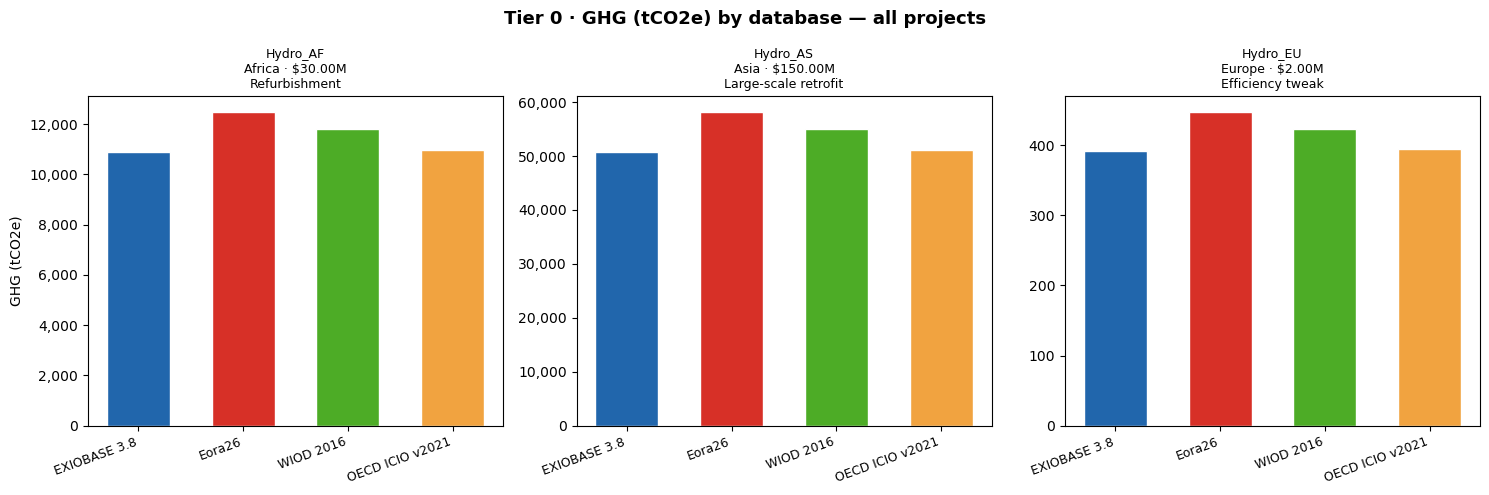

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Tier 0 · GHG (tCO2e) by database — all projects", fontsize=13, fontweight="bold")

for ax, p in zip(axes, PROJECTS):
    sub = t0_df[t0_df["Project"] == p["id"]].reset_index(drop=True)
    ax.bar(range(len(DATABASES)), sub["GHG_tCO2e"],
           color=DB_COLORS, width=0.6, edgecolor="white")
    ax.set_xticks(range(len(DATABASES)))
    ax.set_xticklabels([DB_LABEL[d] for d in DATABASES], rotation=20, ha="right", fontsize=9)
    ax.set_title(f"{p['id']}\n{p['region']} · ${p['invest_usd']/1e6:.2f}M\n"
                 f"{p['impact_type']}", fontsize=9)
    if ax is axes[0]:
        ax.set_ylabel("GHG (tCO2e)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))

plt.tight_layout()
plt.show()


In [9]:
display(Markdown("### Embodied (supply-chain) GHG vs Operational Avoided CO₂ — EXIOBASE 3.8, Tier 0"))
ratio_rows = []
for p in PROJECTS:
    row = next(r for r in t0_rows if r["Project"]==p["id"] and r["Database"]=="EXIOBASE 3.8")
    ratio_rows.append({
        "Project":                  p["id"],
        "Region":                   p["region"],
        "Impact type":              p["impact_type"],
        "Invest_MUSD":              p["invest_usd"] / 1e6,
        "Embodied_GHG_T0_tCO2e":   row["GHG_tCO2e"],
        "Avoided_CO2_yr_tCO2e":    p["avoided_co2"],
        "Payback_years (T0 only)":  round(row["GHG_tCO2e"] / p["avoided_co2"], 2)
            if p["avoided_co2"] > 0 else "N/A",
    })
ratio_df = pd.DataFrame(ratio_rows).set_index("Project")
display(ratio_df)
display(Markdown(
    "> **Carbon payback (Tier 0 only):** number of years of avoided emissions needed "
    "to offset the Tier 0 embodied carbon.  The full cumulative (T0–T10) payback "
    "is shown in Section 8."
))


### Embodied (supply-chain) GHG vs Operational Avoided CO₂ — EXIOBASE 3.8, Tier 0

,Region,Impact type,Invest_MUSD,Embodied_GHG_T0_tCO2e,Avoided_CO2_yr_tCO2e,Payback_years (T0 only)
Project,,,,,,
Hydro_AF,Africa,Refurbishment,30.000,"10,872.230",150000,0.070
Hydro_AS,Asia,Large-scale retrofit,150.000,"50,692.900",834219,0.060
Hydro_EU,Europe,Efficiency tweak,2.000,392.400,6126,0.060


> **Carbon payback (Tier 0 only):** number of years of avoided emissions needed to offset the Tier 0 embodied carbon.  The full cumulative (T0–T10) payback is shown in Section 8.

---
## 5 · Tier 1 — First Upstream Round: Tier 0 Spend Aggregated into the Supply Chain

**Formula:** `y₁ = A · y₀`;  for each sector j:
`impact₁[src] = S(src) · (trade_share[src, j] × y₁[j])`

Tier 1 is **not** the direct spend — that is Tier 0.  Tier 1 is what happens
when the Tier 0 payment propagates one round into the upstream economy: the
civil contractors and turbine manufacturers that received the Tier 0 payment
now buy inputs from their **own** suppliers in different sectors and countries.

For hydro projects this tier is important because:
- **Turbines and generators** (Manufacturing) are highly internationally traded.
  Hydro_AS (Asia) sources most of its large turbines from Chinese and European
  manufacturers; Hydro_AF (Africa) typically imports turbine components from
  Europe or China.  This import leakage is captured at Tier 1 through the
  bilateral trade-share breakdown.
- **Steel and copper** (Mining_Extraction → Manufacturing at Tier 1) are the
  dominant upstream materials, with extraction heavily concentrated in
  specific regions (iron ore: Australia/Brazil; copper: Chile/DRC).

**Trade shares (calibrated fallback):**
Derived from the OECD TiVA 2021 database (`IMSH_D` indicator).  For Africa
the regional import openness is ≈ 30 %; for Asia ≈ 25 %; for Europe ≈ 28 %.
Manufacturing and Mining sectors receive higher foreign shares; Construction and
Water/Waste receive lower foreign shares reflecting local procurement.

When pymrio database files are present under `input_iodb/`, trade shares are
extracted directly from the MRIO Z matrix.


In [10]:
t1_rows = []
for p in PROJECTS:
    for db in DATABASES:
        r = tier1_impact(p["invest_usd"], p["sector_code"], p["region"],
                         database=db, iodb_path=IODB)
        t1_rows.append({
            "Project": p["id"], "Region": p["region"], "Stage": p["stage"],
            "Database": DB_LABEL[db],
            "GHG_tCO2e":      r["GHG_tCO2e"],
            "Employment_FTE": r["Employment_FTE"],
            "Water_1000m3":   r["Water_1000m3"],
            "ValueAdded_M$":  r["ValueAdded_M$"],
            "_sourcing":      r["sourcing_summary"],
            "_by_sector":     r["tier1_by_sector"],
        })
t1_df = pd.DataFrame(t1_rows)
print("Tier 1 computed.")


Tier 1 computed.


In [11]:
display(Markdown("### Tier 1 — All projects × all databases"))
cols = ["Project","Region","Database","GHG_tCO2e","Employment_FTE","Water_1000m3","ValueAdded_M$"]
display(t1_df[cols].set_index(["Project","Database"]))


### Tier 1 — All projects × all databases

Region  GHG_tCO2e  Employment_FTE  Water_1000m3  \
Project  Database                                                           
Hydro_AF EXIOBASE 3.8     Africa  5,020.170         184.460        36.744   
         Eora26           Africa  5,854.590         251.280        43.865   
         WIOD 2016        Africa  5,395.750         257.180        38.232   
         OECD ICIO v2021  Africa  5,021.070         221.030        39.105   
Hydro_AS EXIOBASE 3.8       Asia 24,353.600         879.000       181.766   
         Eora26             Asia 28,407.820       1,197.840       217.019   
         WIOD 2016          Asia 26,165.490       1,224.130       189.146   
         OECD ICIO v2021    Asia 24,354.390       1,052.710       193.466   
Hydro_EU EXIOBASE 3.8     Europe    227.820           7.760         1.645   
         Eora26           Europe    265.960          10.570         1.958   
         WIOD 2016        Europe    244.590          10.800         1.711   
         OECD ICIO v2021  Europe    227.830           9.290         1.751   

                          ValueAdded_M$  
Project  Database                        
Hydro_AF EXIOBASE 3.8             8.670  
         Eora26                   8.827  
         WIOD 2016                8.693  
         OECD ICIO v2021          8.734  
Hydro_AS EXIOBASE 3.8            43.350  
         Eora26                  44.137  
         WIOD 2016               43.467  
         OECD ICIO v2021         43.668  
Hydro_EU EXIOBASE 3.8             0.578  
         Eora26                   0.589  
         WIOD 2016                0.580  
         OECD ICIO v2021          0.582

In [12]:
display(Markdown("### Tier 1 — Sourcing-country GHG breakdown · all projects (EXIOBASE 3.8)"))
for p in PROJECTS:
    display(Markdown(f"**{p['id']} · {p['region']} · {p['impact_type']}**"))
    rec = next(r for r in t1_rows
               if r["Project"] == p["id"] and r["Database"] == "EXIOBASE 3.8")
    src_rows = []
    for region, vals in rec["_sourcing"].items():
        src_rows.append({
            "Sourcing region": region,
            "spend_M$":       vals["spend_M$"],
            "GHG_tCO2e":      vals["GHG_tCO2e"],
            "Employment_FTE": vals["Employment_FTE"],
            "Water_1000m3":   vals["Water_1000m3"],
        })
    display(pd.DataFrame(src_rows).set_index("Sourcing region"))


### Tier 1 — Sourcing-country GHG breakdown · all projects (EXIOBASE 3.8)

**Hydro_AF · Africa · Refurbishment**

,spend_M$,GHG_tCO2e,Employment_FTE,Water_1000m3
Sourcing region,,,,
Europe,1.464,285.070,8.931,1.944
LATAM,0.466,145.147,4.799,0.994
Africa,9.213,"3,207.654",123.998,24.368
Asia,2.663,916.118,31.521,6.495
Global,1.797,466.184,15.215,2.943


**Hydro_AS · Asia · Large-scale retrofit**

,spend_M$,GHG_tCO2e,Employment_FTE,Water_1000m3
Sourcing region,,,,
Europe,6.137,"1,194.581",37.426,8.146
LATAM,1.952,608.237,20.109,4.165
Africa,1.116,411.039,14.509,2.827
Asia,61.277,"20,186.213",743.194,154.295
Global,7.531,"1,953.532",63.758,12.332


**Hydro_EU · Europe · Efficiency tweak**

,spend_M$,GHG_tCO2e,Employment_FTE,Water_1000m3
Sourcing region,,,,
Europe,0.756,138.902,4.750,1.038
LATAM,0.025,7.940,0.263,0.054
Africa,0.015,5.365,0.189,0.037
Asia,0.146,50.112,1.724,0.355
Global,0.098,25.501,0.832,0.161


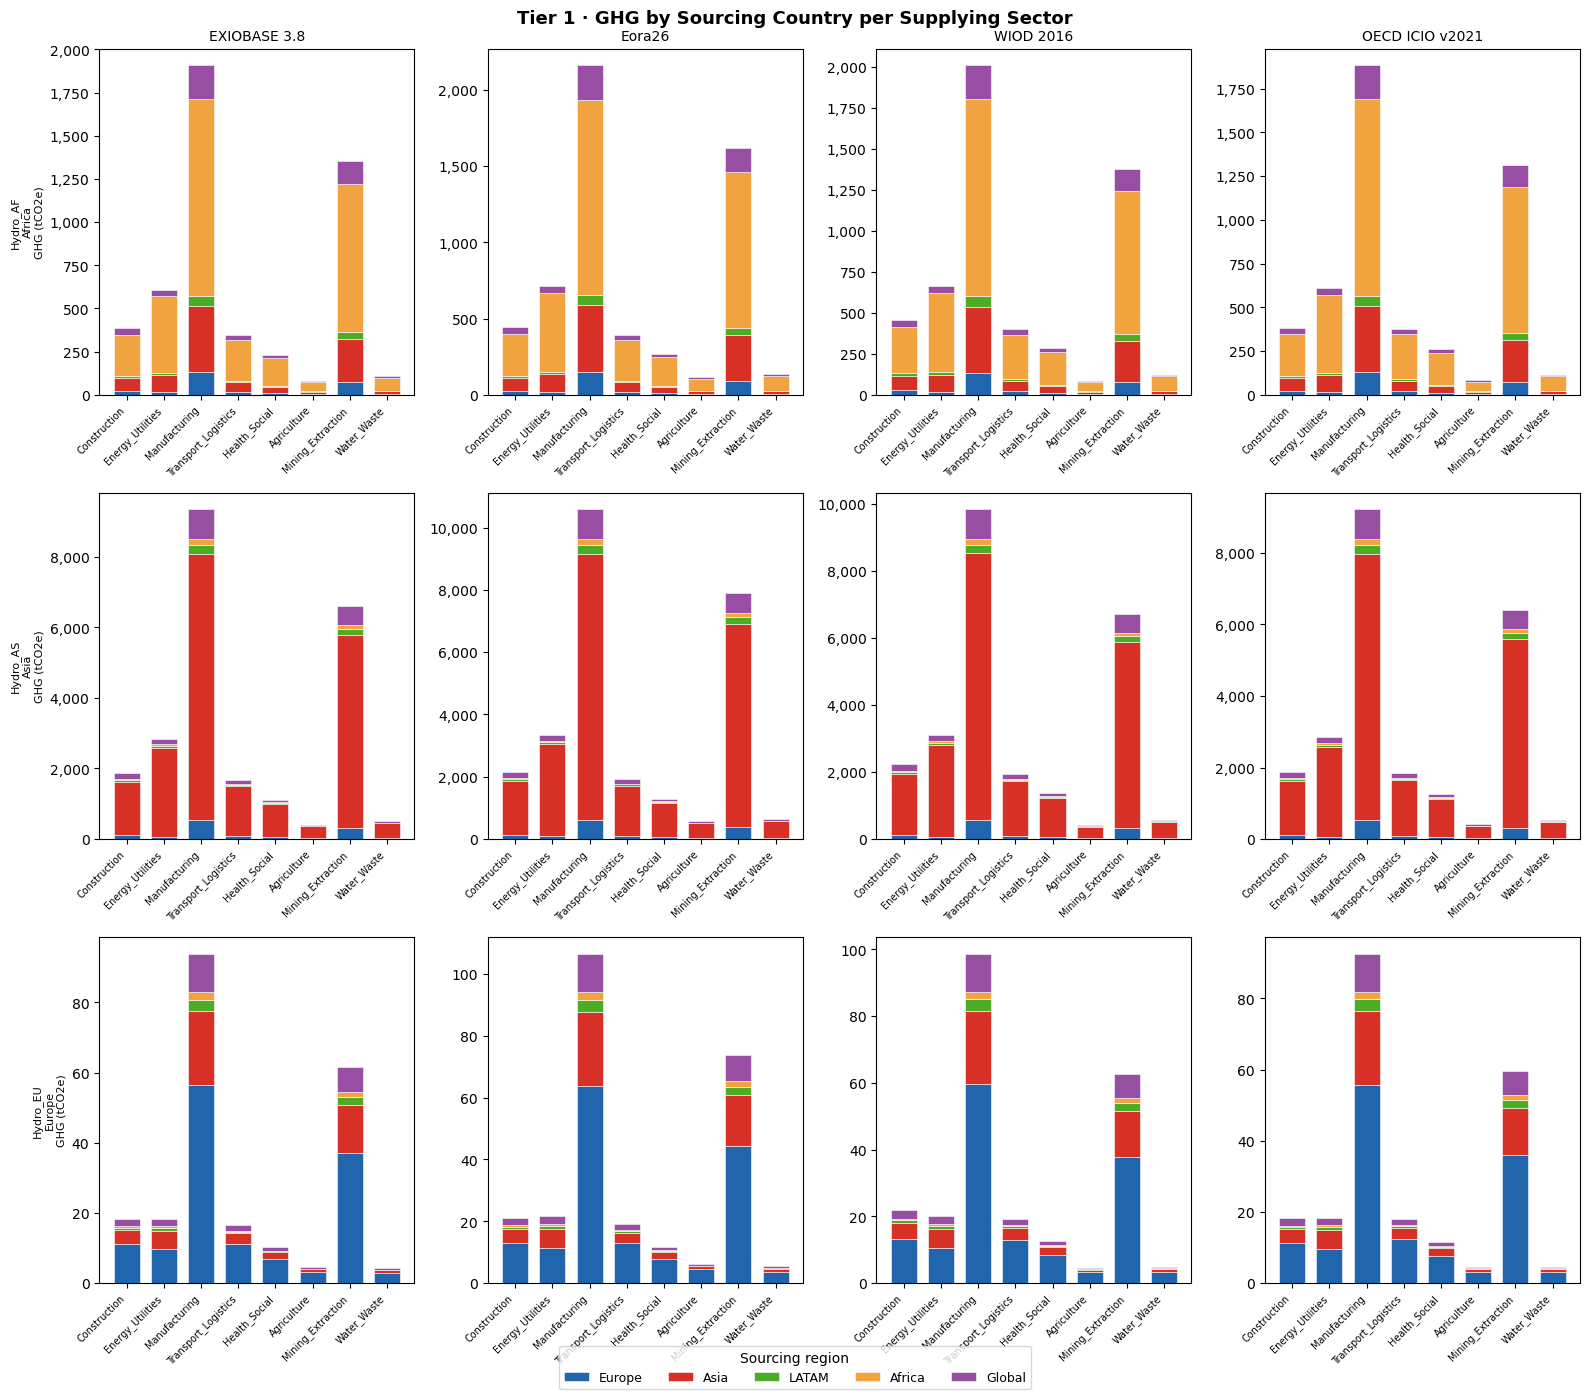

In [13]:
REGION_COLOR = {"Europe":"#2166ac","Asia":"#d73027","LATAM":"#4dac26",
                "Africa":"#f1a340","Global":"#984ea3"}
REGIONS_ORD  = ["Europe","Asia","LATAM","Africa","Global"]

fig, axes = plt.subplots(3, len(DATABASES), figsize=(16, 14), sharey=False)
fig.suptitle("Tier 1 · GHG by Sourcing Country per Supplying Sector",
             fontsize=13, fontweight="bold")

for row_idx, p in enumerate(PROJECTS):
    for col_idx, db in enumerate(DATABASES):
        ax  = axes[row_idx][col_idx]
        rec = next(r for r in t1_rows
                   if r["Project"] == p["id"] and r["Database"] == DB_LABEL[db])
        sectors = list(rec["_by_sector"].keys())
        bottom  = np.zeros(len(sectors))
        for reg in REGIONS_ORD:
            vals = [rec["_by_sector"][s].get(reg, {}).get("GHG_tCO2e", 0) for s in sectors]
            ax.bar(range(len(sectors)), vals, bottom=bottom, label=reg,
                   color=REGION_COLOR.get(reg, "#aaa"), width=0.7,
                   edgecolor="white", lw=0.4)
            bottom += np.array(vals)
        ax.set_xticks(range(len(sectors)))
        ax.set_xticklabels(sectors, rotation=45, ha="right", fontsize=7)
        if col_idx == 0:
            ax.set_ylabel(f"{p['id']}\n{p['region']}\nGHG (tCO2e)", fontsize=8)
        if row_idx == 0:
            ax.set_title(DB_LABEL[db], fontsize=10)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))

handles, labels = axes[0][-1].get_legend_handles_labels()
fig.legend(handles, labels, title="Sourcing region",
           loc="lower center", ncol=5, bbox_to_anchor=(0.5, -0.01), fontsize=9)
plt.tight_layout()
plt.show()


---
## 6 · Tier 2 — Second Upstream Round

**Formula:** `y₂ = A² · y₀`

Tier 2 is the supply chain of the Tier 1 suppliers — two rounds back from
the direct investment.  For hydro projects the key Tier 2 flows are:
- **Iron ore and coal** (Mining_Extraction) feeding the steel mills that
  supply turbine and generator manufacturers.
- **Copper ore** (Mining_Extraction) feeding the copper smelters that supply
  transformer and winding manufacturers.
- **Energy generation inputs** for the electricity supply chain itself.

By Tier 2, Mining_Extraction and Energy_Utilities together typically account
for > 60 % of the GHG impact for energy-sector projects.

**Decay:** Tier 2 totals ≈ 0.52 × Tier 1 totals (spectral radius of A_BASE ≈ 0.52).
Sourcing-country breakdown is not computed at Tier 2 and above; project-region
intensity is applied uniformly.


In [14]:
t2_rows = []
for p in PROJECTS:
    for db in DATABASES:
        df2 = tier_impact(p["invest_usd"], p["sector_code"], p["region"],
                          database=db, iodb_path=IODB, tier_from=2, tier_to=2)
        t2_rows.append({
            "Project": p["id"], "Region": p["region"], "Stage": p["stage"],
            "Database": DB_LABEL[db],
            "GHG_tCO2e":      round(df2["GHG_tCO2e"].sum(), 2),
            "Employment_FTE": round(df2["Employment_FTE"].sum(), 2),
            "Water_1000m3":   round(df2["Water_1000m3"].sum(), 4),
            "ValueAdded_M$":  round(df2["ValueAdded_M$"].sum(), 4),
            "_df": df2,
        })
t2_df = pd.DataFrame(t2_rows)

display(Markdown("### Tier 2 — All projects × all databases"))
cols = ["Project","Region","Database","GHG_tCO2e","Employment_FTE","Water_1000m3","ValueAdded_M$"]
display(t2_df[cols].set_index(["Project","Database"]))


### Tier 2 — All projects × all databases

Region  GHG_tCO2e  Employment_FTE  Water_1000m3  \
Project  Database                                                           
Hydro_AF EXIOBASE 3.8     Africa  2,593.020          99.860        20.344   
         Eora26           Africa  3,059.380         138.680        24.735   
         WIOD 2016        Africa  2,775.890         139.230        21.180   
         OECD ICIO v2021  Africa  2,580.030         119.690        21.680   
Hydro_AS EXIOBASE 3.8       Asia 12,090.280         453.990        97.846   
         Eora26             Asia 14,263.490         630.600       118.954   
         WIOD 2016          Asia 12,937.690         631.880       101.888   
         OECD ICIO v2021    Asia 12,027.370         543.680       104.290   
Hydro_EU EXIOBASE 3.8     Europe     90.210           3.130         0.707   
         Eora26           Europe    106.390           4.340         0.855   
         WIOD 2016        Europe     96.530           4.360         0.736   
         OECD ICIO v2021  Europe     89.770           3.750         0.754   

                          ValueAdded_M$  
Project  Database                        
Hydro_AF EXIOBASE 3.8             4.168  
         Eora26                   4.301  
         WIOD 2016                4.173  
         OECD ICIO v2021          4.193  
Hydro_AS EXIOBASE 3.8            20.843  
         Eora26                  21.503  
         WIOD 2016               20.868  
         OECD ICIO v2021         20.965  
Hydro_EU EXIOBASE 3.8             0.278  
         Eora26                   0.287  
         WIOD 2016                0.278  
         OECD ICIO v2021          0.280

In [15]:
display(Markdown("### Tier 2 — Sector detail per project (EXIOBASE 3.8)"))
for p in PROJECTS:
    display(Markdown(f"**{p['id']} · {p['region']} · {p['impact_type']}**"))
    df2_proj = next(r["_df"] for r in t2_rows
                    if r["Project"] == p["id"] and r["Database"] == "EXIOBASE 3.8")
    detail_cols = ["supplying_sector","spend_M$","GHG_tCO2e","Employment_FTE",
                   "Water_1000m3","ValueAdded_M$"]
    display(df2_proj[detail_cols].set_index("supplying_sector"))


### Tier 2 — Sector detail per project (EXIOBASE 3.8)

**Hydro_AF · Africa · Refurbishment**

,spend_M$,GHG_tCO2e,Employment_FTE,Water_1000m3,ValueAdded_M$
supplying_sector,,,,,
Construction,0.620,185.178,12.339,0.746,0.298
Energy_Utilities,1.108,351.882,7.131,2.084,0.709
Manufacturing,1.882,947.279,20.135,4.204,0.790
Transport_Logistics,0.806,180.677,10.860,0.660,0.484
Health_Social,0.639,119.501,16.596,0.865,0.448
Agriculture,0.320,52.610,10.405,2.557,0.243
Mining_Extraction,1.610,689.547,15.073,4.228,0.901
Water_Waste,0.429,66.349,7.320,5.000,0.296


**Hydro_AS · Asia · Large-scale retrofit**

,spend_M$,GHG_tCO2e,Employment_FTE,Water_1000m3,ValueAdded_M$
supplying_sector,,,,,
Construction,3.099,859.754,53.887,3.415,1.488
Energy_Utilities,5.538,"1,555.690",31.801,9.597,3.545
Manufacturing,9.408,"4,461.823",94.054,20.469,3.952
Transport_Logistics,4.032,855.478,50.630,3.205,2.419
Health_Social,3.197,555.429,72.736,4.047,2.238
Agriculture,1.598,258.355,48.507,12.011,1.214
Mining_Extraction,8.049,"3,247.865",70.405,20.584,4.507
Water_Waste,2.145,295.881,31.969,24.518,1.480


**Hydro_EU · Europe · Efficiency tweak**

,spend_M$,GHG_tCO2e,Employment_FTE,Water_1000m3,ValueAdded_M$
supplying_sector,,,,,
Construction,0.041,6.878,0.354,0.024,0.020
Energy_Utilities,0.074,6.420,0.231,0.074,0.047
Manufacturing,0.125,36.610,0.636,0.151,0.053
Transport_Logistics,0.054,7.300,0.382,0.024,0.032
Health_Social,0.043,4.264,0.492,0.030,0.030
Agriculture,0.021,2.662,0.319,0.072,0.016
Mining_Extraction,0.107,23.984,0.476,0.148,0.060
Water_Waste,0.029,2.092,0.241,0.183,0.020


---
## 7 · Tiers 3–10 — Deep Upstream Rounds

**Formula:** `yₙ = Aⁿ · y₀` for n ∈ {3, …, 10}

Each successive tier decays at approximately the spectral radius of the
calibrated A matrix.  For the global EXIOBASE average:

| Tier | Approx. share of Tier 0 signal |
|---|---|
| 3 | ~27 % |
| 4 | ~14 % |
| 5 | ~7 % |
| 6 | ~4 % |
| 7 | ~2 % |
| 8–10 | < 1 % each |

For hydro projects, deeper tiers are dominated by the extraction supply chains
of metals and fuels: iron ore mining → pig iron → steel → turbine (already
captured at Tier 2), and then the mining of coking coal and limestone used in
steelmaking (Tiers 3–4).  By Tier 5 the signal has effectively converged.

Beyond Tier 10 the residual is < 0.5 % for this A matrix.


In [16]:
t310_store = {}   # (project_id, db) → full DataFrame

for p in PROJECTS:
    for db in DATABASES:
        df310 = tier_impact(p["invest_usd"], p["sector_code"], p["region"],
                            database=db, iodb_path=IODB, tier_from=3, tier_to=10)
        t310_store[(p["id"], db)] = df310

print("Tiers 3–10 computed.")


Tiers 3–10 computed.


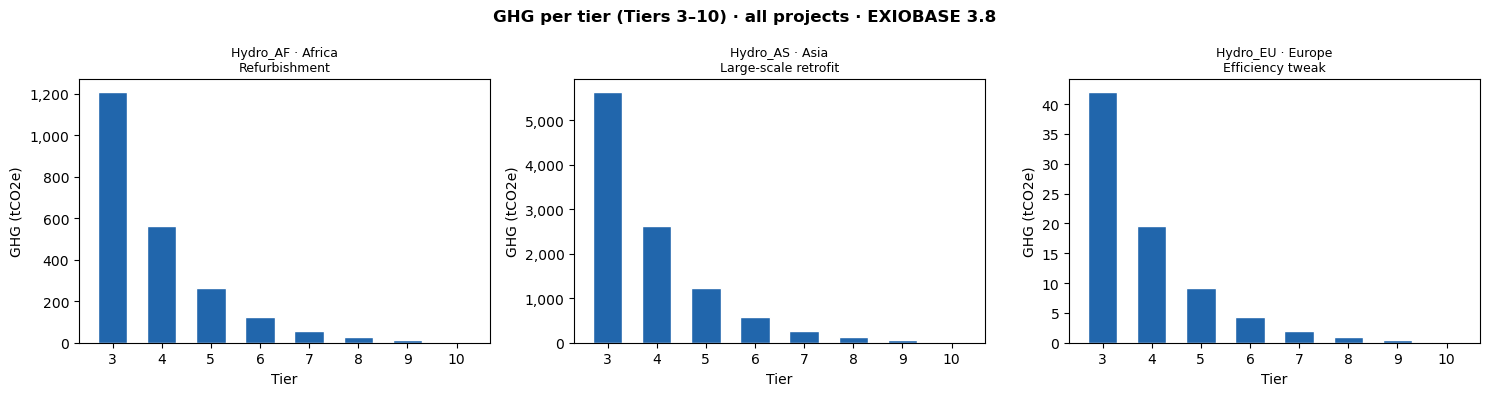

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("GHG per tier (Tiers 3–10) · all projects · EXIOBASE 3.8",
             fontsize=12, fontweight="bold")

for ax, p in zip(axes, PROJECTS):
    decay_df = (t310_store[(p["id"], "exiobase")]
                .groupby("tier")["GHG_tCO2e"].sum().reset_index().set_index("tier"))
    ax.bar(decay_df.index, decay_df["GHG_tCO2e"],
           color="#2166ac", width=0.6, edgecolor="white")
    ax.set_xlabel("Tier")
    ax.set_ylabel("GHG (tCO2e)")
    ax.set_title(f"{p['id']} · {p['region']}\n{p['impact_type']}", fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))

plt.tight_layout()
plt.show()


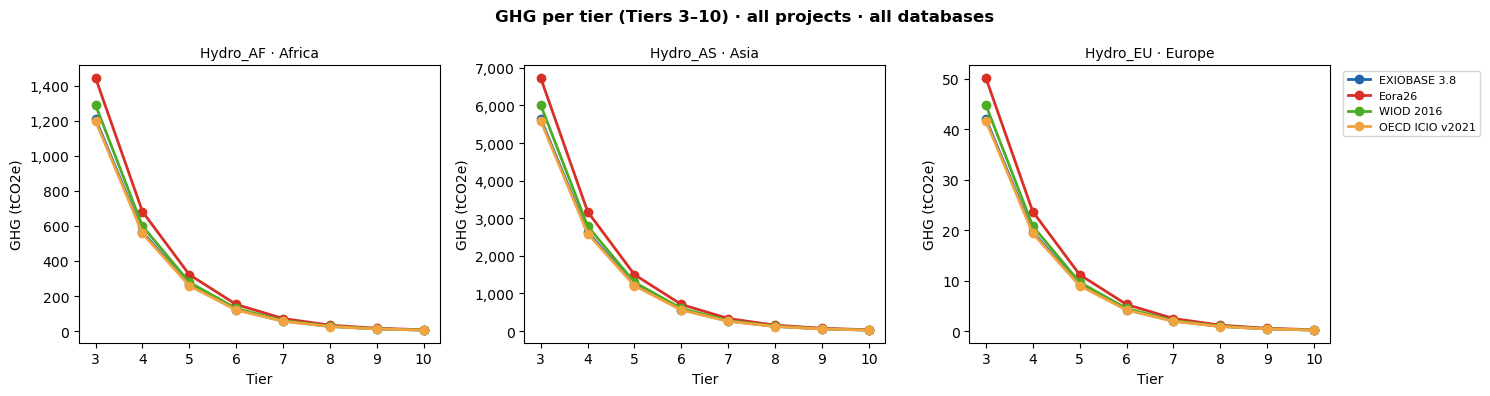

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("GHG per tier (Tiers 3–10) · all projects · all databases",
             fontsize=12, fontweight="bold")

for ax, p in zip(axes, PROJECTS):
    for db, color in zip(DATABASES, DB_COLORS):
        df310 = t310_store[(p["id"], db)]
        by_tier = df310.groupby("tier")["GHG_tCO2e"].sum().reset_index()
        ax.plot(by_tier["tier"], by_tier["GHG_tCO2e"],
                marker="o", label=DB_LABEL[db], color=color, linewidth=2)
    ax.set_xlabel("Tier")
    ax.set_ylabel("GHG (tCO2e)")
    ax.set_title(f"{p['id']} · {p['region']}", fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))

axes[-1].legend(fontsize=8, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [19]:
t310_agg_rows = []
for p in PROJECTS:
    for db in DATABASES:
        df310 = t310_store[(p["id"], db)]
        t310_agg_rows.append({
            "Project": p["id"], "Region": p["region"], "Database": DB_LABEL[db],
            "GHG_tCO2e":      round(df310["GHG_tCO2e"].sum(), 2),
            "Employment_FTE": round(df310["Employment_FTE"].sum(), 2),
            "Water_1000m3":   round(df310["Water_1000m3"].sum(), 4),
            "ValueAdded_M$":  round(df310["ValueAdded_M$"].sum(), 4),
        })
t310_agg_df = pd.DataFrame(t310_agg_rows)

display(Markdown("### Tiers 3–10 — Aggregate (sum of Tiers 3 to 10) · all projects × databases"))
display(t310_agg_df.set_index(["Project","Database"]))


### Tiers 3–10 — Aggregate (sum of Tiers 3 to 10) · all projects × databases

Region  GHG_tCO2e  Employment_FTE  Water_1000m3  \
Project  Database                                                           
Hydro_AF EXIOBASE 3.8     Africa  2,263.280          88.150        18.084   
         Eora26           Africa  2,728.110         125.370        22.531   
         WIOD 2016        Africa  2,402.370         122.120        18.719   
         OECD ICIO v2021  Africa  2,233.180         104.980        19.161   
Hydro_AS EXIOBASE 3.8       Asia 10,551.500         400.760        86.963   
         Eora26             Asia 12,717.020         570.060       108.336   
         WIOD 2016          Asia 11,195.040         554.170        90.037   
         OECD ICIO v2021    Asia 10,408.830         476.870        92.159   
Hydro_EU EXIOBASE 3.8     Europe     78.690           2.760         0.627   
         Eora26           Europe     94.780           3.920         0.777   
         WIOD 2016        Europe     83.460           3.820         0.650   
         OECD ICIO v2021  Europe     77.630           3.290         0.665   

                          ValueAdded_M$  
Project  Database                        
Hydro_AF EXIOBASE 3.8             3.671  
         Eora26                   3.875  
         WIOD 2016                3.650  
         OECD ICIO v2021          3.667  
Hydro_AS EXIOBASE 3.8            18.354  
         Eora26                  19.375  
         WIOD 2016               18.248  
         OECD ICIO v2021         18.334  
Hydro_EU EXIOBASE 3.8             0.245  
         Eora26                   0.258  
         WIOD 2016                0.243  
         OECD ICIO v2021          0.244

---
## 8 · Cumulative Analysis — T0 + T1 + T2 + T3–10

Summing across all tier groups gives the full supply-chain (embodied) GHG
footprint of the hydro investment.  The key question for hydro projects is:
**how many years of avoided operational emissions are needed to offset the
embodied supply-chain carbon?** — i.e. the carbon payback period.

The residual beyond Tier 10 is < 0.5 % for this A matrix.


In [20]:
cumul_rows = []
for p in PROJECTS:
    for db in DATABASES:
        lbl = DB_LABEL[db]
        g0 = next(r["GHG_tCO2e"]      for r in t0_rows  if r["Project"]==p["id"] and r["Database"]==lbl)
        e0 = next(r["Employment_FTE"]  for r in t0_rows  if r["Project"]==p["id"] and r["Database"]==lbl)
        w0 = next(r["Water_1000m3"]    for r in t0_rows  if r["Project"]==p["id"] and r["Database"]==lbl)
        v0 = next(r["ValueAdded_M$"]   for r in t0_rows  if r["Project"]==p["id"] and r["Database"]==lbl)
        g1 = next(r["GHG_tCO2e"]      for r in t1_rows  if r["Project"]==p["id"] and r["Database"]==lbl)
        e1 = next(r["Employment_FTE"]  for r in t1_rows  if r["Project"]==p["id"] and r["Database"]==lbl)
        w1 = next(r["Water_1000m3"]    for r in t1_rows  if r["Project"]==p["id"] and r["Database"]==lbl)
        v1 = next(r["ValueAdded_M$"]   for r in t1_rows  if r["Project"]==p["id"] and r["Database"]==lbl)
        g2 = next(r["GHG_tCO2e"]      for r in t2_rows  if r["Project"]==p["id"] and r["Database"]==lbl)
        e2 = next(r["Employment_FTE"]  for r in t2_rows  if r["Project"]==p["id"] and r["Database"]==lbl)
        w2 = next(r["Water_1000m3"]    for r in t2_rows  if r["Project"]==p["id"] and r["Database"]==lbl)
        v2 = next(r["ValueAdded_M$"]   for r in t2_rows  if r["Project"]==p["id"] and r["Database"]==lbl)
        r310 = next(r for r in t310_agg_rows if r["Project"]==p["id"] and r["Database"]==lbl)
        total_ghg = round(g0+g1+g2+r310["GHG_tCO2e"], 2)
        cumul_rows.append({
            "Project": p["id"], "Region": p["region"], "Database": lbl,
            "GHG_T0": g0, "GHG_T1": g1, "GHG_T2": g2, "GHG_T3_10": r310["GHG_tCO2e"],
            "GHG_Total": total_ghg,
            "Emp_T0": e0, "Emp_T1": e1, "Emp_T2": e2, "Emp_T3_10": r310["Employment_FTE"],
            "Emp_Total": round(e0+e1+e2+r310["Employment_FTE"], 2),
            "Wat_Total": round(w0+w1+w2+r310["Water_1000m3"], 4),
            "VA_Total":  round(v0+v1+v2+r310["ValueAdded_M$"], 4),
        })
cumul_df = pd.DataFrame(cumul_rows)

display(Markdown("### Cumulative GHG by tier group (tCO2e)"))
display(cumul_df[["Project","Region","Database",
                  "GHG_T0","GHG_T1","GHG_T2","GHG_T3_10","GHG_Total"]]
        .set_index(["Project","Database"]))

display(Markdown("### Cumulative totals — all four indicators"))
display(cumul_df[["Project","Region","Database","GHG_Total","Emp_Total","Wat_Total","VA_Total"]]
        .set_index(["Project","Database"]))


### Cumulative GHG by tier group (tCO2e)

Region     GHG_T0     GHG_T1     GHG_T2  GHG_T3_10  \
Project  Database                                                              
Hydro_AF EXIOBASE 3.8     Africa 10,872.230  5,020.170  2,593.020  2,263.280   
         Eora26           Africa 12,483.450  5,854.590  3,059.380  2,728.110   
         WIOD 2016        Africa 11,790.160  5,395.750  2,775.890  2,402.370   
         OECD ICIO v2021  Africa 10,969.170  5,021.070  2,580.030  2,233.180   
Hydro_AS EXIOBASE 3.8       Asia 50,692.900 24,353.600 12,090.280 10,551.500   
         Eora26             Asia 58,167.890 28,407.820 14,263.490 12,717.020   
         WIOD 2016          Asia 54,941.860 26,165.490 12,937.690 11,195.040   
         OECD ICIO v2021    Asia 51,136.690 24,354.390 12,027.370 10,408.830   
Hydro_EU EXIOBASE 3.8     Europe    392.400    227.820     90.210     78.690   
         Eora26           Europe    447.520    265.960    106.390     94.780   
         WIOD 2016        Europe    423.250    244.590     96.530     83.460   
         OECD ICIO v2021  Europe    395.250    227.830     89.770     77.630   

                           GHG_Total  
Project  Database                     
Hydro_AF EXIOBASE 3.8     20,748.700  
         Eora26           24,125.530  
         WIOD 2016        22,364.170  
         OECD ICIO v2021  20,803.450  
Hydro_AS EXIOBASE 3.8     97,688.280  
         Eora26          113,556.220  
         WIOD 2016       105,240.080  
         OECD ICIO v2021  97,927.280  
Hydro_EU EXIOBASE 3.8        789.120  
         Eora26              914.650  
         WIOD 2016           847.830  
         OECD ICIO v2021     790.480

### Cumulative totals — all four indicators

Region   GHG_Total  Emp_Total  Wat_Total  VA_Total
Project  Database                                                           
Hydro_AF EXIOBASE 3.8     Africa  20,748.700    812.770    133.822    31.641
         Eora26           Africa  24,125.530  1,090.820    156.803    32.135
         WIOD 2016        Africa  22,364.170  1,114.830    138.799    31.648
         OECD ICIO v2021  Africa  20,803.450    961.750    141.671    31.725
Hydro_AS EXIOBASE 3.8       Asia  97,688.280  3,707.170    646.269   158.206
         Eora26             Asia 113,556.220  4,977.300    757.503   160.675
         WIOD 2016          Asia 105,240.080  5,082.500    670.386   158.243
         OECD ICIO v2021    Asia  97,927.280  4,386.500    684.276   158.627
Hydro_EU EXIOBASE 3.8     Europe     789.120     26.970      5.016     2.109
         Eora26           Europe     914.650     36.230      5.871     2.142
         WIOD 2016        Europe     847.830     37.020      5.203     2.110
         OECD ICIO v2021  Europe     790.480     31.950      5.314     2.115

In [21]:
display(Markdown("### Carbon payback — embodied GHG (T0–T10) vs operational avoided CO₂ · EXIOBASE 3.8"))
payback_rows = []
for p in PROJECTS:
    row = next(r for r in cumul_rows if r["Project"]==p["id"] and r["Database"]=="EXIOBASE 3.8")
    payback_rows.append({
        "Project":                    p["id"],
        "Region":                     p["region"],
        "Impact type":                p["impact_type"],
        "Invest_MUSD":                round(p["invest_usd"]/1e6, 3),
        "Embodied_GHG_T0_T10_tCO2e": row["GHG_Total"],
        "Avoided_CO2_per_yr_tCO2e":  p["avoided_co2"],
        "Payback_years (T0–T10)":     round(row["GHG_Total"] / p["avoided_co2"], 2)
                                      if p["avoided_co2"] > 0 else "N/A",
        "Emp_Total_FTE":              row["Emp_Total"],
    })
payback_df = pd.DataFrame(payback_rows).set_index("Project")
display(payback_df)
display(Markdown(
    "> A payback < 1 year means the full embodied supply-chain carbon is offset within "
    "the first year of avoided emissions — typical for large-scale hydro retrofits "
    "displacing coal-heavy generation (Hydro_AS).  A payback > 5 years suggests the "
    "embodied carbon is a meaningful fraction of the project's lifetime avoided emissions."
))


### Carbon payback — embodied GHG (T0–T10) vs operational avoided CO₂ · EXIOBASE 3.8

,Region,Impact type,Invest_MUSD,Embodied_GHG_T0_T10_tCO2e,Avoided_CO2_per_yr_tCO2e,Payback_years (T0–T10),Emp_Total_FTE
Project,,,,,,,
Hydro_AF,Africa,Refurbishment,30.000,"20,748.700",150000,0.140,812.770
Hydro_AS,Asia,Large-scale retrofit,150.000,"97,688.280",834219,0.120,"3,707.170"
Hydro_EU,Europe,Efficiency tweak,2.000,789.120,6126,0.130,26.970


> A payback < 1 year means the full embodied supply-chain carbon is offset within the first year of avoided emissions — typical for large-scale hydro retrofits displacing coal-heavy generation (Hydro_AS).  A payback > 5 years suggests the embodied carbon is a meaningful fraction of the project's lifetime avoided emissions.

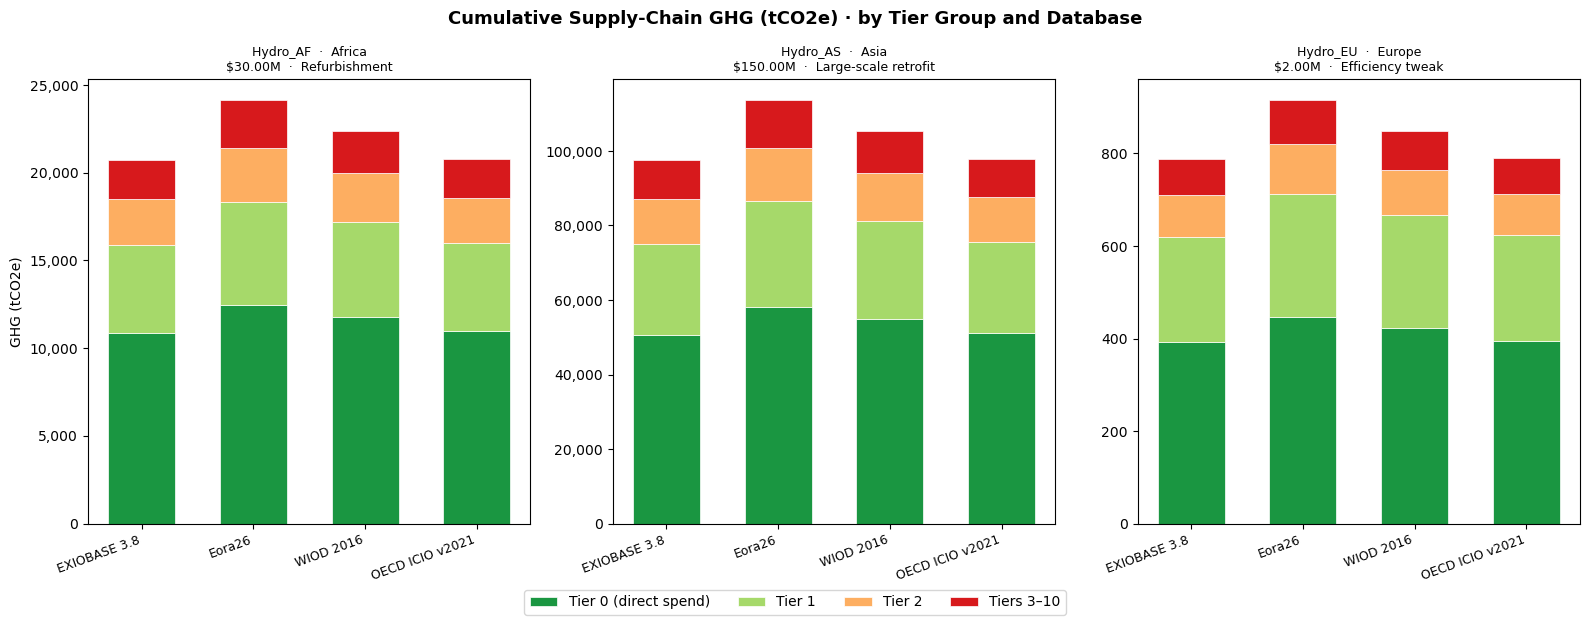

In [22]:
TIER_COLOR = {"T0": "#1a9641", "T1": "#a6d96a", "T2": "#fdae61", "T3_10": "#d7191c"}
TIER_LABEL = {"T0": "Tier 0 (direct spend)", "T1": "Tier 1",
              "T2": "Tier 2", "T3_10": "Tiers 3–10"}

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Cumulative Supply-Chain GHG (tCO2e) · by Tier Group and Database",
             fontsize=13, fontweight="bold")

for ax, p in zip(axes, PROJECTS):
    sub    = cumul_df[cumul_df["Project"] == p["id"]].reset_index(drop=True)
    x      = range(len(DATABASES))
    bottom = np.zeros(len(DATABASES))
    for tier_key in ["T0","T1","T2","T3_10"]:
        col  = f"GHG_{tier_key}"
        vals = sub[col].values
        ax.bar(x, vals, bottom=bottom, label=TIER_LABEL[tier_key],
               color=TIER_COLOR[tier_key], width=0.6, edgecolor="white", linewidth=0.5)
        bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels([DB_LABEL[d] for d in DATABASES], rotation=20, ha="right", fontsize=9)
    ax.set_title(f"{p['id']}  ·  {p['region']}\n${p['invest_usd']/1e6:.2f}M  ·  {p['impact_type']}",
                 fontsize=9)
    if ax is axes[0]:
        ax.set_ylabel("GHG (tCO2e)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4,
           bbox_to_anchor=(0.5, -0.04), fontsize=10, frameon=True)
plt.tight_layout()
plt.show()
